## Load dữ liệu

In [2]:
import pandas as pd
import os

DATA_DIR = '../data/raw'

# Đọc dữ liệu và tự động nhận diện cột Date
sales = pd.read_csv(os.path.join(DATA_DIR, "sales.csv"), parse_dates=["Date"])
test = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"), parse_dates=["Date"])
promotions = pd.read_csv(os.path.join(DATA_DIR, "promotions.csv"), parse_dates=["start_date", "end_date"])

## Các Hàm xử lý

In [4]:
# Hàm trộn dữ liệu khuyến mãi vào bảng bán hàng
def merge_promotions(df_main, df_promo):
    df = df_main.copy()
    promo = df_promo.copy()
    
    # Tạo key ảo để thực hiện Cross Join
    df['key'] = 1
    promo['key'] = 1
    merged = pd.merge(df, promo, on='key').drop('key', axis=1)
    
    # Lọc các dòng khớp điều kiện thời gian khuyến mãi
    condition = (merged['Date'] >= merged['start_date']) & (merged['Date'] <= merged['end_date'])
    matched_promo = merged[condition].copy()
    
    # Giữ lại chương trình có mức giảm giá cao nhất nếu có nhiều khuyến mãi trùng ngày
    matched_promo = matched_promo.sort_values('discount_value', ascending=False).drop_duplicates('Date')
    
    # Ghép (Left Join) trở lại bảng ban đầu
    final_df = pd.merge(df.drop('key', axis=1), matched_promo, on=list(df.drop('key', axis=1).columns), how='left')
    
    # Dọn dẹp dữ liệu (Điền 0 cho số, 'No_Promo' cho chữ)
    cols_to_fill_zero = ['discount_value', 'stackable_flag', 'min_order_value']
    final_df[cols_to_fill_zero] = final_df[cols_to_fill_zero].fillna(0)
    
    cols_to_fill_text = ['promo_id', 'promo_name', 'promo_type', 'applicable_category', 'promo_channel']
    final_df[cols_to_fill_text] = final_df[cols_to_fill_text].fillna('No_Promo')
    final_df = final_df.drop(columns=['start_date', 'end_date'])
    
    return final_df

# Hàm bẻ nhỏ thời gian
def create_features_v2(df):
    df = df.copy()
    df['day'] = df['Date'].dt.day
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
    df['quarter'] = df['Date'].dt.quarter
    
    # Đặc trưng ngày Lễ/Sale cố định tại VN
    holidays_and_sales = ['01-01', '02-14', '03-08', '04-30', '05-01', '09-02', '10-20', '11-11', '12-12', '12-24']
    df['month_day'] = df['Date'].dt.strftime('%m-%d')
    df['is_holiday'] = df['month_day'].apply(lambda x: 1 if x in holidays_and_sales else 0)
    df = df.drop(columns=['month_day'])
    return df

print("Đang trộn dữ liệu Khuyến mãi...")
sales_merged = merge_promotions(sales, promotions)
test_merged = merge_promotions(test, promotions)

print("Đang tạo đặc trưng thời gian...")
train_v3 = create_features_v2(sales_merged)
test_v3 = create_features_v2(test_merged)

Đang trộn dữ liệu Khuyến mãi...
Đang tạo đặc trưng thời gian...


## ONE-HOT ENCODING

In [5]:
print("Đang mã hóa One-Hot Encoding...")
categorical_cols = ['promo_id', 'promo_name', 'promo_type', 'applicable_category', 'promo_channel']

train_encoded = pd.get_dummies(train_v3, columns=categorical_cols)
test_encoded = pd.get_dummies(test_v3, columns=categorical_cols)

# Ép 2 bảng phải có số lượng và tên cột khớp nhau 100%
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

Đang mã hóa One-Hot Encoding...


## Chạy model

In [6]:
import xgboost as xgb

# Tự động lấy tất cả các cột trừ Date và Revenue
FEATURES = [col for col in train_encoded.columns if col not in ['Date', 'Revenue']]
TARGET = 'Revenue'

X_train = train_encoded[FEATURES]
y_train = train_encoded[TARGET]
X_test = test_encoded[FEATURES]
Y_test = test_encoded[TARGET] 


print("Đang huấn luyện Hội đồng XGBoost V3...")
reg_v3 = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    reg_alpha=0.5,
    reg_lambda=1.5,
    random_state=42
)

reg_v3.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train)],
    verbose=100
)

# Chạy dự báo cho tập Test
predictions_v3 = reg_v3.predict(X_test)

Đang huấn luyện Hội đồng XGBoost V3...
[0]	validation_0-rmse:2501343.95675
[100]	validation_0-rmse:156721.89752
[200]	validation_0-rmse:126739.54824
[300]	validation_0-rmse:118019.18978
[400]	validation_0-rmse:109949.98079
[500]	validation_0-rmse:102023.67743
[600]	validation_0-rmse:96264.43871
[700]	validation_0-rmse:92574.99012
[800]	validation_0-rmse:88486.77148
[900]	validation_0-rmse:85030.84400
[999]	validation_0-rmse:81383.81845


## Xuất file csv

In [7]:
# Trích xuất 3 cột yêu cầu: Date, Revenue, COGS
submission_v3 = test_merged[['Date', 'COGS']].copy()
submission_v3['Revenue'] = predictions_v3

# Sắp xếp lại thứ tự cột cho đẹp (Date, Revenue, COGS)
submission_v3 = submission_v3[['Date', 'Revenue', 'COGS']]

# Xuất ra file CSV
submission_v3.to_csv('final_submission_v3.csv', index=False)
print("\nHoàn tất! Đã lưu thành công file final_submission_v3.csv sẵn sàng để nộp bài.")


Hoàn tất! Đã lưu thành công file final_submission_v3.csv sẵn sàng để nộp bài.


## Kiểm tra toán

In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Kiểm tra xem tập Test có cột Revenue thực tế để chấm điểm hay không
if Y_test.notna().all():
    mae_v3 = mean_absolute_error(Y_test, predictions_v3)
    rmse_v3 = np.sqrt(mean_squared_error(Y_test, predictions_v3))
    r2_v3 = r2_score(Y_test, predictions_v3)

    print(f"\n--- ĐÁNH GIÁ MÔ HÌNH V3 ---")
    print(f"MAE  : {mae_v3:,.2f}")
    print(f"RMSE : {rmse_v3:,.2f}")
    print(f"R²   : {r2_v3:.4f}")
else:
    print("\n[Thông báo] Tập Test hiện tại không chứa giá trị Revenue thực tế để chấm điểm.")
    print("Dữ liệu đã sẵn sàng để xuất file Submission!")


--- ĐÁNH GIÁ MÔ HÌNH V3 ---
MAE  : 205,673.08
RMSE : 318,213.17
R²   : 0.9595


## Vẽ biều đồ

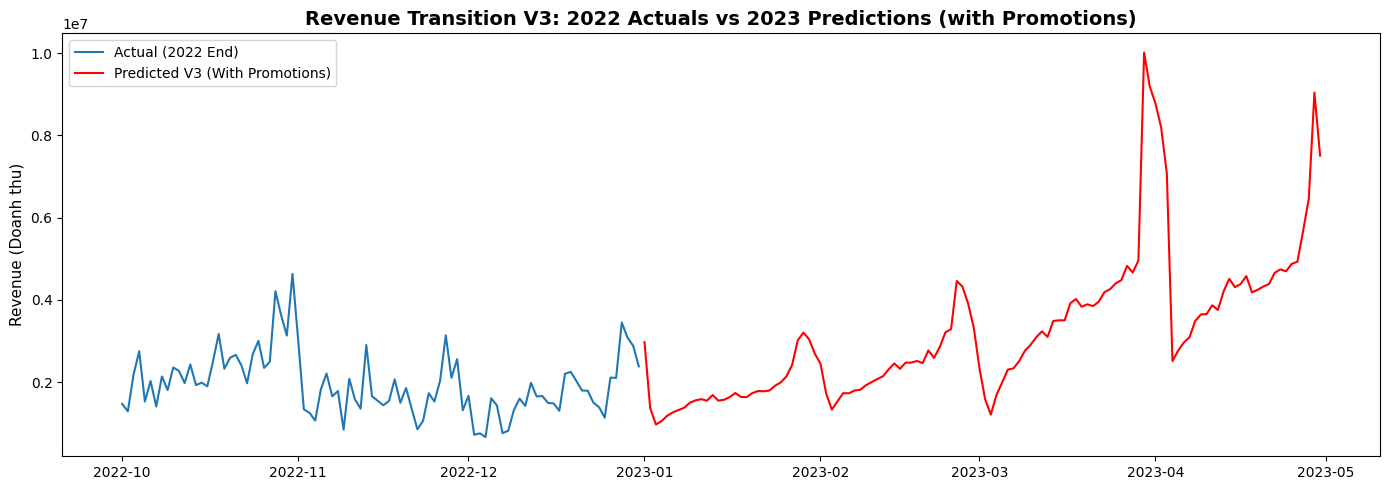

In [11]:
import matplotlib.pyplot as plt

test_merged['predicted_Revenue_V3'] = predictions_v3
# Lọc dữ liệu Thực tế (Actuals) - Lấy 3 tháng cuối năm 2022 từ tập sales_merged
train_zoomed = sales_merged[(sales_merged['Date'] >= '2022-10-01') & (sales_merged['Date'] <= '2022-12-31')]

# Lọc dữ liệu Dự báo (Predictions) - Lấy 4 tháng đầu năm 2023 từ tập test_merged
# Lưu ý: Chúng ta dùng cột 'predicted_Revenue_V3' đã được mô hình dự báo
test_zoomed = test_merged[(test_merged['Date'] >= '2023-01-01') & (test_merged['Date'] <= '2023-04-30')]

# Khởi tạo khung biểu đồ với kích thước chuẩn
plt.figure(figsize=(14, 5)) 

# Vẽ đường Thực tế (Màu xanh dương)
plt.plot(train_zoomed['Date'], train_zoomed['Revenue'], 
         label='Actual (2022 End)', color='#1f77b4', linewidth=1.5)

# Vẽ đường Dự báo V3 (Màu đỏ chói)
plt.plot(test_zoomed['Date'], test_zoomed['predicted_Revenue_V3'], 
         label='Predicted V3 (With Promotions)', color='red', linewidth=1.5)

# Trang trí biểu đồ y hệt như ảnh mẫu của bạn
plt.title('Revenue Transition V3: 2022 Actuals vs 2023 Predictions (with Promotions)', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (Doanh thu)', fontsize=11)
plt.legend(loc='upper left', fontsize=10)

# Tinh chỉnh layout để các thông số không bị che khuất
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()